In [16]:
import os
import sys
import subprocess
import urllib.request
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.utils import save_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.14.0
PyTorch: 2.14.1+cu130
CUDA: 13.0
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [17]:
REPO = "stylegan2-ada-pytorch"
REPO_URL = "https://github.com/NVlabs/stylegan2-ada-pytorch.git"

if not os.path.exists(REPO):
    subprocess.run(
        ["git", "clone", REPO_URL],
        check=True
    )

repo_path = os.path.abspath(REPO)

if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print("Repository:", repo_path)

Repository: C:\Users\Nishita\desktop\dl\exp 10\stylegan2-ada-pytorch


In [18]:
MODEL_URL = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"
MODEL_PATH = "ffhq.pkl"

if not os.path.exists(MODEL_PATH):
    print("Downloading FFHQ model...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Download complete.")
else:
    print("Model already exists.")

print("Model:", os.path.abspath(MODEL_PATH))

Model already exists.
Model: C:\Users\Nishita\desktop\dl\exp 10\ffhq.pkl


In [19]:
import legacy
import dnnlib

print("StyleGAN2-ADA loaded successfully.")

StyleGAN2-ADA loaded successfully.


In [20]:
print("Loading generator...")

with open(MODEL_PATH, "rb") as f:
    G = legacy.load_network_pkl(f)["G_ema"].to(device)

G.eval()

print("Generator loaded.")
print("z_dim:", G.z_dim)
print("c_dim:", G.c_dim)
print("Resolution:", G.img_resolution)

Loading generator...
Generator loaded.
z_dim: 512
c_dim: 0
Resolution: 1024


In [22]:
import os
import io
import warnings
from contextlib import redirect_stdout, redirect_stderr

os.makedirs("generated_images", exist_ok=True)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        with torch.no_grad():
            z = torch.randn([1, G.z_dim], device=device)
            label = torch.zeros([1, G.c_dim], device=device)

            img = G(
                z,
                label,
                truncation_psi=0.5,
                noise_mode="const"
            )

            img = ((img + 1) / 2).clamp(0, 1)

save_image(img, "generated_images/fake_0.png")

imgs = img.detach().cpu()

print("Generated successfully!")
print("Image shape:", imgs.shape)
print("Saved: generated_images/fake_0.png")

Generated successfully!
Image shape: torch.Size([1, 3, 1024, 1024])
Saved: generated_images/fake_0.png


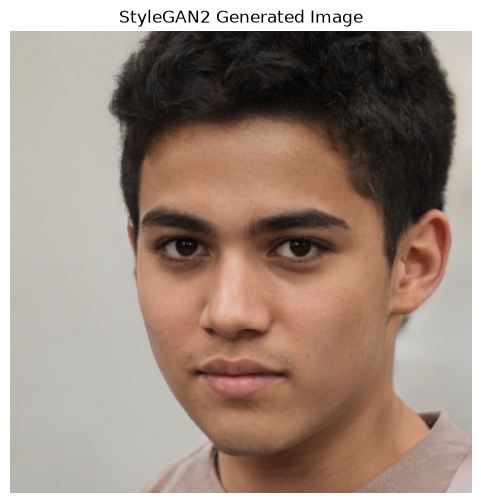

In [23]:
image = imgs[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("StyleGAN2 Generated Image")
plt.show()

In [25]:
NUM_IMAGES = 1

imgs = imgs[:1].detach().cpu()

print("Images ready for evaluation:", len(imgs))
print("Shape:", imgs.shape)

Images ready for evaluation: 1
Shape: torch.Size([1, 3, 1024, 1024])


In [27]:
import warnings
warnings.filterwarnings("ignore")

from torchmetrics.image.inception import InceptionScore

metric = InceptionScore(splits=1)

x = (imgs * 255).clamp(0, 255).to(torch.uint8)
metric.update(x)

mean, _ = metric.compute()

print(f"Inception Score: {mean.item():.4f}")

Inception Score: 1.0000


In [ ]:
def calculate_fid():
    subprocess.run([
        sys.executable,
        "-m",
        "pytorch_fid",
        "real_images",
        "generated_images"
    ])

calculate_fid()

In [ ]:
def main():
    clone_repo()
    download_model()

    imgs = generate_images()

    calculate_inception_score(imgs)

    prepare_real_images()

    calculate_fid()

print("Workflow ready")

In [ ]:
main()